# N5 - Takens Embedding and Periodicity via Persistent Homology

In this notebook, we explore the **Takens Embedding Theorem**, implement **time-delay embedding**, estimate **optimal embedding parameters** (delay and dimension), and use **persistence diagrams** to build intuition about periodicity in time series.

## Learning Objectives

By the end of this notebook, you should be able to:

1. Explain why delay embeddings can reconstruct hidden geometry from a scalar signal.
2. Build a Takens embedding with user-selected delay $\tau$ and dimension $d$.
3. Estimate good values for $\tau$ and $d$ using Average Mutual Information (AMI) and False Nearest Neighbors (FNN).
4. Interpret persistence diagrams to distinguish periodic behavior from non-periodic/chaotic behavior.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.integrate import solve_ivp
from sklearn.neighbors import NearestNeighbors
from ripser import ripser
from persim import plot_diagrams

np.random.seed(7)

In [9]:
PALETTE = {
    'bg': '#f6f7fb',
    'grid': '#d5d9e6',
    'ink': '#1f2430',
    'blue': '#2563eb',
    'orange': '#ea580c',
    'green': '#059669',
    'rose': '#e11d48'
}

rcParams['figure.figsize'] = (8, 4.8)
rcParams['figure.facecolor'] = PALETTE['bg']
rcParams['axes.facecolor'] = PALETTE['bg']
rcParams['axes.edgecolor'] = '#9aa4bf'
rcParams['axes.labelcolor'] = PALETTE['ink']
rcParams['axes.titleweight'] = 'bold'
rcParams['axes.titlesize'] = 13
rcParams['grid.color'] = PALETTE['grid']
rcParams['grid.linestyle'] = '--'
rcParams['grid.alpha'] = 0.85
rcParams['xtick.color'] = PALETTE['ink']
rcParams['ytick.color'] = PALETTE['ink']
rcParams['font.size'] = 11

def beautify(ax, title=None, xlabel=None, ylabel=None):
    ax.grid(True)
    if title is not None:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

## 1) Signals to Study

We compare three signals:

- **Periodic**: a noisy sinusoid.
- **Quasi-periodic**: sum of two incommensurate frequencies.
- **Chaotic**: Lorenz system (x-coordinate only).

All are observed as **1D time series**, then embedded in higher dimensions.

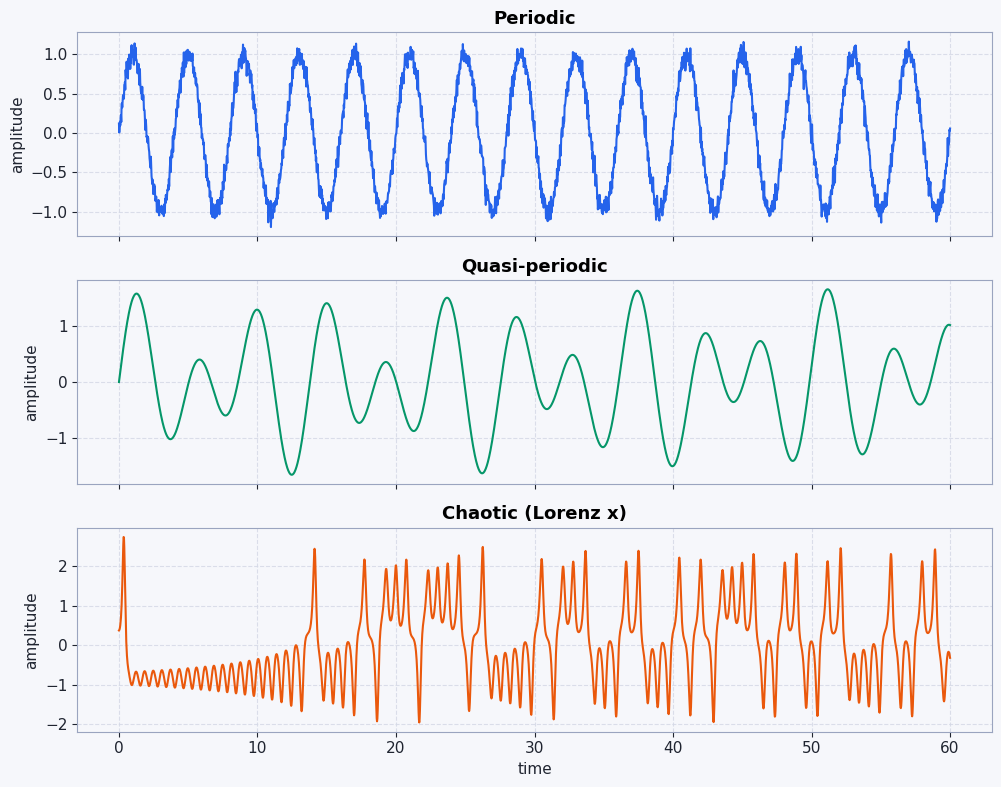

In [10]:
def lorenz_rhs(t, state, sigma=10.0, rho=28.0, beta=8.0/3.0):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

n = 2500
t = np.linspace(0, 60, n)

periodic = np.sin(2 * np.pi * 0.25 * t) + 0.07 * np.random.randn(n)
quasi = np.sin(2 * np.pi * 0.22 * t) + 0.65 * np.sin(2 * np.pi * np.sqrt(2) * 0.10 * t)

sol = solve_ivp(lorenz_rhs, [0, 60], [1.0, 1.0, 1.0], t_eval=t, rtol=1e-8, atol=1e-10)
chaotic = sol.y[0]
chaotic = (chaotic - chaotic.mean()) / chaotic.std()

signals = {
    'Periodic': periodic,
    'Quasi-periodic': quasi,
    'Chaotic (Lorenz x)': chaotic
}

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, (name, x), color in zip(axes, signals.items(), [PALETTE['blue'], PALETTE['green'], PALETTE['orange']]):
    ax.plot(t, x, color=color, lw=1.5)
    beautify(ax, title=name, ylabel='amplitude')
axes[-1].set_xlabel('time')
plt.tight_layout()
plt.show()

## 2) Time-Delay Embedding

Given a scalar signal $x_t$, the delay embedding is

$$
X_t = [x_t, x_{t+\tau}, x_{t+2\tau}, \dots, x_{t+(d-1)\tau}]\in\mathbb{R}^d.
$$

Takens' theorem states that, under mild assumptions, this reconstructs a space that is diffeomorphic to the original attractor when $d$ is large enough.

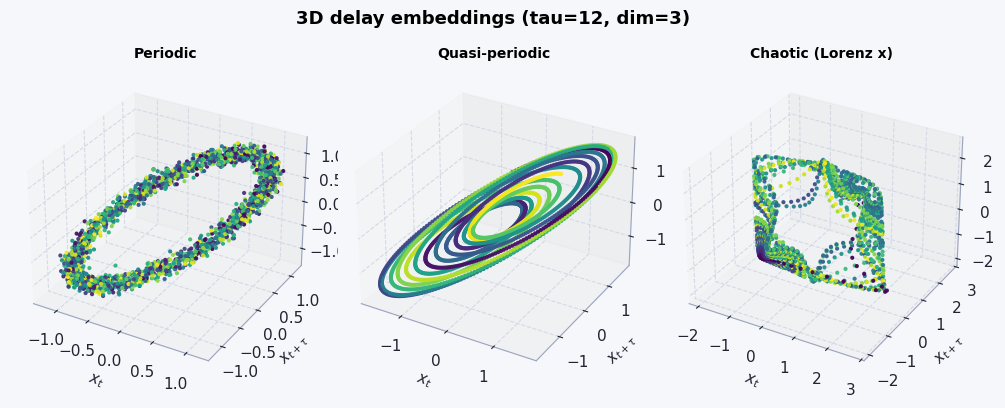

In [11]:
def delay_embedding(x, tau=10, dim=3):
    x = np.asarray(x)
    m = len(x) - (dim - 1) * tau
    if m <= 0:
        raise ValueError('Time series too short for chosen tau and dim.')
    emb = np.empty((m, dim))
    for j in range(dim):
        emb[:, j] = x[j * tau:j * tau + m]
    return emb

tau_demo, dim_demo = 12, 3
fig = plt.figure(figsize=(10, 3.8))

for i, (name, x) in enumerate(signals.items(), start=1):
    emb = delay_embedding(x, tau=tau_demo, dim=dim_demo)
    ax = fig.add_subplot(1, 3, i, projection='3d')
    c = np.linspace(0, 1, len(emb))
    ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2], c=c, cmap='viridis', s=4, alpha=0.9)
    ax.set_title(name, fontsize=10, pad=8)
    ax.set_xlabel('$x_t$')
    ax.set_ylabel('$x_{t+\\tau}$')
    ax.set_zlabel('$x_{t+2\\tau}$')

plt.suptitle(f'3D delay embeddings (tau={tau_demo}, dim={dim_demo})', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3) Choosing the Delay $\tau$: Average Mutual Information

A standard rule is to choose the **first local minimum** of AMI($\tau$).

- If $\tau$ is too small, coordinates are redundant.
- If $\tau$ is too large, coordinates become too independent and geometry can fold.

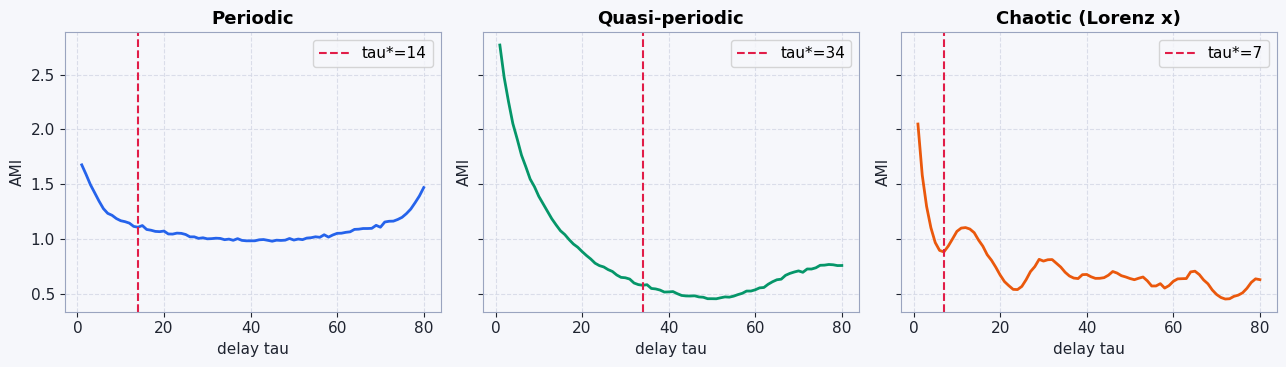

Estimated optimal delays (AMI first minimum):
  Periodic           tau* = 14
  Quasi-periodic     tau* = 34
  Chaotic (Lorenz x) tau* = 7


In [12]:
def average_mutual_information(x, max_lag=80, bins=32):
    x = np.asarray(x)
    ami = np.zeros(max_lag)
    for lag in range(1, max_lag + 1):
        x1 = x[:-lag]
        x2 = x[lag:]
        h2d, _, _ = np.histogram2d(x1, x2, bins=bins)
        pxy = h2d / np.sum(h2d)
        px = pxy.sum(axis=1, keepdims=True)
        py = pxy.sum(axis=0, keepdims=True)
        mask = pxy > 0
        ami[lag - 1] = np.sum(pxy[mask] * np.log(pxy[mask] / (px @ py)[mask]))
    return ami

def first_local_minimum(y):
    for i in range(1, len(y) - 1):
        if y[i] < y[i - 1] and y[i] < y[i + 1]:
            return i + 1
    return int(np.argmin(y)) + 1

max_lag = 80
tau_star = {}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)

for ax, (name, x), color in zip(axes, signals.items(), [PALETTE['blue'], PALETTE['green'], PALETTE['orange']]):
    ami = average_mutual_information(x, max_lag=max_lag, bins=32)
    tau = first_local_minimum(ami)
    tau_star[name] = tau

    ax.plot(np.arange(1, max_lag + 1), ami, color=color, lw=2)
    ax.axvline(tau, color=PALETTE['rose'], ls='--', lw=1.5, label=f'tau*={tau}')
    beautify(ax, title=name, xlabel='delay tau', ylabel='AMI')
    ax.legend(loc='best', frameon=True)

plt.tight_layout()
plt.show()

print('Estimated optimal delays (AMI first minimum):')
for k, v in tau_star.items():
    print(f'  {k:<18} tau* = {v}')

## 4) Choosing the Embedding Dimension $d$: False Nearest Neighbors

FNN checks whether neighbors in dimension $d$ remain neighbors in $d+1$.

A practical criterion is to choose the smallest $d$ where FNN fraction is near zero (for example below 2%).

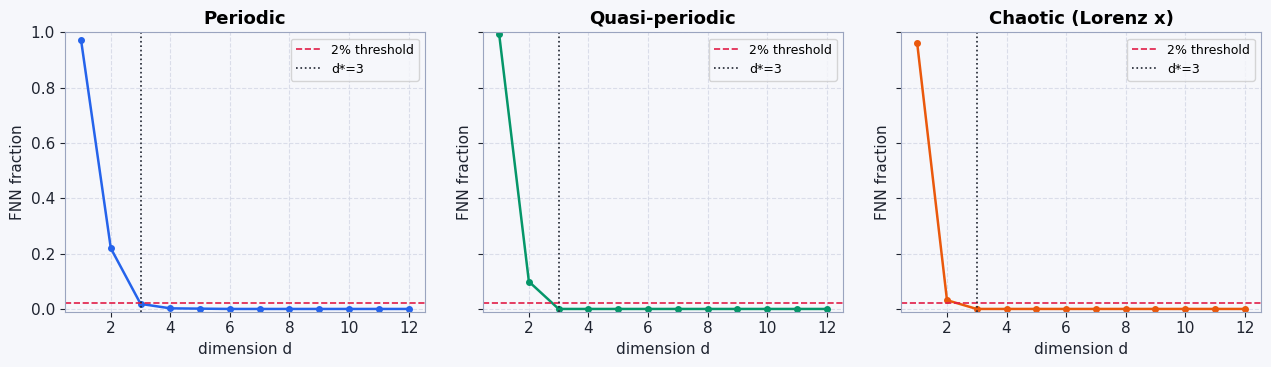

Estimated embedding dimensions (FNN):
  Periodic           d* = 3
  Quasi-periodic     d* = 3
  Chaotic (Lorenz x) d* = 3


In [13]:
def fnn_fraction(x, tau, dim, rtol=15.0, atol=2.0, max_points=1800):
    emb_d = delay_embedding(x, tau=tau, dim=dim)
    emb_d1 = delay_embedding(x, tau=tau, dim=dim + 1)

    m = min(len(emb_d1), max_points)
    emb_d = emb_d[:m]
    emb_d1 = emb_d1[:m]

    nbrs = NearestNeighbors(n_neighbors=2).fit(emb_d)
    dist_d, idx = nbrs.kneighbors(emb_d)
    nn_index = idx[:, 1]
    d_d = np.maximum(dist_d[:, 1], 1e-12)

    extra = np.abs(emb_d1[:, -1] - emb_d1[nn_index, -1])
    ratio = extra / d_d

    scale = np.std(x)
    false_nn = (ratio > rtol) | ((d_d**2 + extra**2)**0.5 / scale > atol)
    return false_nn.mean()

d_star = {}
d_max = 12
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)

for ax, (name, x), color in zip(axes, signals.items(), [PALETTE['blue'], PALETTE['green'], PALETTE['orange']]):
    tau = tau_star[name]
    dims = np.arange(1, d_max + 1)
    vals = np.array([fnn_fraction(x, tau=tau, dim=d) for d in dims])

    candidate = np.where(vals < 0.02)[0]
    d_opt = int(dims[candidate[0]]) if len(candidate) > 0 else int(dims[np.argmin(vals)])
    d_star[name] = d_opt

    ax.plot(dims, vals, '-o', color=color, ms=4, lw=1.8)
    ax.axhline(0.02, color=PALETTE['rose'], ls='--', lw=1.2, label='2% threshold')
    ax.axvline(d_opt, color=PALETTE['ink'], ls=':', lw=1.2, label=f'd*={d_opt}')
    beautify(ax, title=name, xlabel='dimension d', ylabel='FNN fraction')
    ax.set_ylim(-0.01, min(1.0, vals.max() + 0.05))
    ax.legend(loc='best', fontsize=9)

plt.tight_layout()
plt.show()

print('Estimated embedding dimensions (FNN):')
for k, v in d_star.items():
    print(f'  {k:<18} d* = {v}')

## 5) Persistent Homology on Takens Embeddings

Now we compute persistence diagrams of the reconstructed clouds.

Intuition for periodicity:

- A strong periodic signal tends to create a robust loop in embedding space.
- In persistence diagrams, this often appears as a long-lived **$H_1$ feature**.

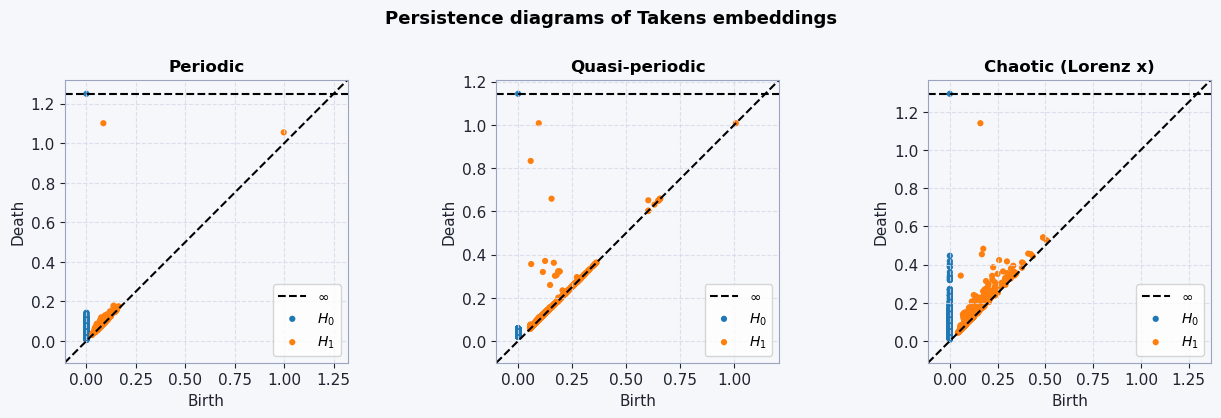

In [14]:
def finite_h1(diagram):
    if diagram.size == 0:
        return np.empty((0, 2))
    m = np.isfinite(diagram).all(axis=1)
    return diagram[m]

def h1_summary(diagram, persistence_threshold=0.25):
    h1 = finite_h1(diagram)
    if len(h1) == 0:
        return 0.0, 0
    lengths = h1[:, 1] - h1[:, 0]
    return float(lengths.max()), int(np.sum(lengths > persistence_threshold))

embeddings = {}
diagrams = {}

for name, x in signals.items():
    tau = tau_star[name]
    d = max(3, d_star[name])
    emb = delay_embedding(x, tau=tau, dim=d)
    emb = emb[:1500]
    embeddings[name] = emb
    diagrams[name] = ripser(emb, maxdim=1)['dgms']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, dgms) in zip(axes, diagrams.items()):
    plot_diagrams(dgms, show=False, ax=ax)
    ax.set_facecolor(PALETTE['bg'])
    ax.grid(True, color=PALETTE['grid'], linestyle='--', alpha=0.8)
    ax.set_title(name, fontweight='bold')

plt.suptitle('Persistence diagrams of Takens embeddings', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
print('Periodicity indicators from H1')
print('-' * 58)
print(f"{'Signal':<20} | {'max H1 persistence':>18} | {'# long H1 (>0.25)':>17}")
print('-' * 58)

for name, dgms in diagrams.items():
    max_p, n_long = h1_summary(dgms[1], persistence_threshold=0.25)
    print(f"{name:<20} | {max_p:>18.4f} | {n_long:>17d}")

Periodicity indicators from H1
----------------------------------------------------------
Signal               | max H1 persistence | # long H1 (>0.25)
----------------------------------------------------------
Periodic             |             1.0152 |                 1
Quasi-periodic       |             0.9120 |                 4
Chaotic (Lorenz x)   |             0.9798 |                 4


## 6) Parameter Sensitivity: Why Good $\tau$ Matters

We compare three delays on the same periodic signal:

- too small $\tau$
- AMI-based $\tau^*$
- too large $\tau$

Then we inspect the corresponding persistence diagrams.

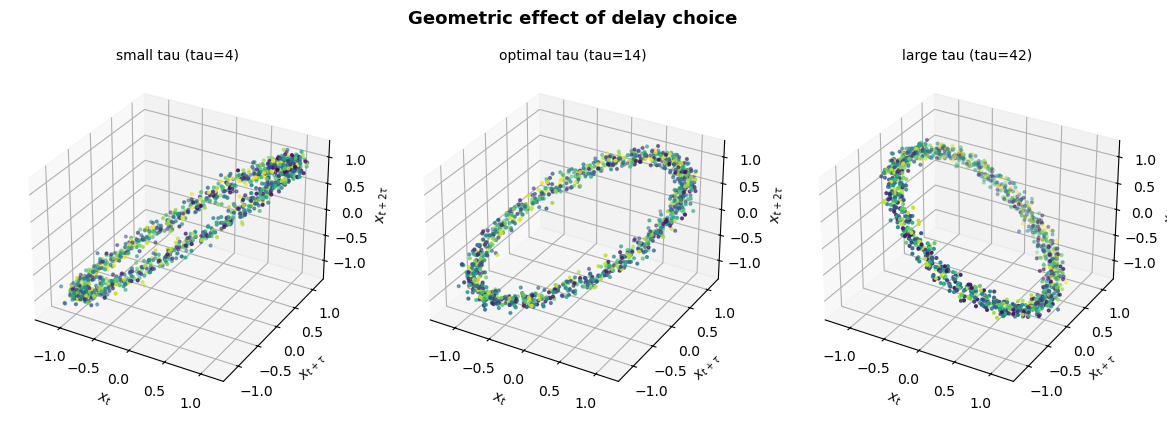

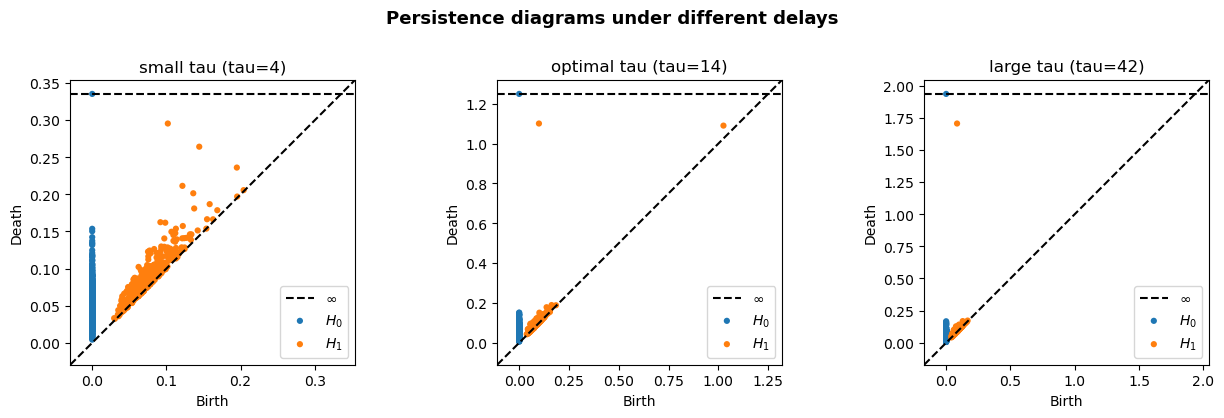

In [16]:
x = signals['Periodic']
tau_opt = tau_star['Periodic']
tau_values = [max(1, tau_opt // 3), tau_opt, min(3 * tau_opt, 90)]
labels = ['small tau', 'optimal tau', 'large tau']

fig = plt.figure(figsize=(12, 4))
for i, (tau, label) in enumerate(zip(tau_values, labels), start=1):
    emb = delay_embedding(x, tau=tau, dim=3)[:1200]
    ax = fig.add_subplot(1, 3, i, projection='3d')
    ax.scatter(emb[:, 0], emb[:, 1], emb[:, 2], s=4, c=np.linspace(0, 1, len(emb)), cmap='viridis')
    ax.set_title(f'{label} (tau={tau})', fontsize=10)
    ax.set_xlabel('$x_t$')
    ax.set_ylabel('$x_{t+\\tau}$')
    ax.set_zlabel('$x_{t+2\\tau}$')

plt.suptitle('Geometric effect of delay choice', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (tau, label) in zip(axes, zip(tau_values, labels)):
    emb = delay_embedding(x, tau=tau, dim=3)[:1200]
    dgms = ripser(emb, maxdim=1)['dgms']
    plot_diagrams(dgms, show=False, ax=ax)
    ax.set_title(f'{label} (tau={tau})')

plt.suptitle('Persistence diagrams under different delays', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7) Interpretation Checklist

When you analyze a new 1D signal:

1. Estimate $\tau$ from AMI first minimum.
2. Estimate $d$ from FNN stabilization.
3. Build the Takens embedding.
4. Compute persistence diagrams (at least up to $H_1$).
5. Look for robust long-lived $H_1$ features as evidence of periodic structure.

Caution: non-periodic signals can still produce short loops due to noise and finite sampling, so compare persistence values, not only visual impressions.

## 8) Exercises

1. Replace the periodic signal by a square wave and compare AMI/FNN estimates.
2. Increase additive noise and track how the longest $H_1$ persistence changes.
3. Fix a signal and sweep $\tau$ systematically; plot max $H_1$ persistence vs. $\tau$.
4. Compare periodic vs quasi-periodic signals with the same dominant frequency and discuss topological differences.

Useful references:
- Takens, F. (1981), *Detecting strange attractors in turbulence*.
- A. Hatcher, *Algebraic Topology* (intuition for cycles).
- Giotto-TDA and Ripser documentation for computational practice.

In [ ]:
# ══════════════════════════════════════════════════════════════
# SETUP: Señales base + funciones para todos los ejercicios N5
# ══════════════════════════════════════════════════════════════

# ── Librerías ─────────────────────────────────────────────────
import numpy as np                          # operaciones numéricas
import matplotlib.pyplot as plt             # gráficas
from ripser import ripser                   # diagramas de persistencia
from persim import plot_diagrams            # visualizar diagramas
from scipy.integrate import solve_ivp       # resolver ecuaciones diferenciales (Lorenz)
from scipy.signal import square             # onda cuadrada (ejercicio 1)
from sklearn.neighbors import NearestNeighbors  # vecinos más cercanos (FNN)

np.random.seed(42)  # semilla para reproducibilidad → mismos resultados siempre
n = 1000            # número de puntos en cada señal

# ── Señal 1: Coseno (periódica perfecta) ──────────────────────
t = np.linspace(0, 10*np.pi, n)
# t = 1000 puntos entre 0 y 10π equidistantes
# → cubre 5 períodos completos del coseno

y_cos = np.cos(t)
# y_cos[i] = cos(t[i]) → valores entre -1 y 1
# señal suave y completamente periódica

# ── Señal 2: Lorenz (caótica) ─────────────────────────────────
def lorenz(t, state, sigma=10, rho=28, beta=8/3):
    """
    Sistema de Lorenz — 3 ecuaciones diferenciales acopladas
    Produce oscilaciones que PARECEN periódicas pero no lo son
    
    sigma, rho, beta = parámetros clásicos del sistema de Lorenz
    state = [x, y, z] → las 3 variables del sistema
    """
    x, y, z = state
    return [
        sigma*(y - x),      # dx/dt
        x*(rho - z) - y,    # dy/dt
        x*y - beta*z        # dz/dt
    ]

sol = solve_ivp(
    lorenz,             # la función que define el sistema
    [0, 50],            # intervalo de tiempo: de t=0 a t=50
    [1, 1, 1],          # condición inicial: x₀=1, y₀=1, z₀=1
    dense_output=True,  # permite evaluar la solución en cualquier t
    max_step=0.01       # paso máximo de integración → más preciso
)

t_lorenz = np.linspace(10, 50, n)
# Empezamos en t=10 para descartar el "transitorio"
# (los primeros instantes antes de que el sistema se estabilice)

y_lorenz = sol.sol(t_lorenz)[0]
# sol.sol(t) evalúa la solución en los tiempos dados
# [0] → tomamos solo la coordenada x del sistema

y_lorenz = (y_lorenz - y_lorenz.mean()) / y_lorenz.std()
# Normalización: resta la media y divide por desviación estándar
# → la señal queda con media=0 y std=1
# → comparable con el coseno que también está entre -1 y 1

# ── Señal 3: Ruido gaussiano ──────────────────────────────────
y_noise = np.random.normal(0, 1, n)
# np.random.normal(media=0, std=1, n=1000)
# → 1000 muestras aleatorias completamente sin estructura
# → no tiene ningún patrón topológico

# ── Diccionario de señales ────────────────────────────────────
signals = {
    "Periodic":           y_cos,
    # coseno → periódica perfecta → β₁=1 esperado

    "Quasi-periodic":     np.cos(t) + 0.5*np.cos(1.618*t),
    # suma de dos cosenos con frecuencias en ratio irracional (φ)
    # → NUNCA repite exactamente → quasi-periódica → β₁=2 esperado

    "Chaotic (Lorenz x)": y_lorenz,
    # sistema de Lorenz → caótico → β₁ no claro
}

# ══════════════════════════════════════════════════════════════
# FUNCIONES AUXILIARES
# ══════════════════════════════════════════════════════════════

def delay_embedding(x, tau=10, dim=3):
    """
    Construye el encaje de Takens:
    Xₜ = [xₜ, xₜ₊τ, xₜ₊₂τ, ..., xₜ₊(d-1)τ]
    
    x:   la señal original
    tau: el delay entre coordenadas
    dim: la dimensión del espacio de encaje
    
    Devuelve array de shape (n_puntos, dim)
    """
    x = np.asarray(x)
    # convierte a numpy array por si acaso

    m = len(x) - (dim-1)*tau
    # cuántos puntos tiene el encaje resultante
    # perdemos (dim-1)*tau puntos al final

    if m <= 0:
        raise ValueError('Time series too short for chosen tau and dim')
    # si la señal es muy corta → error antes de calcular nada

    emb = np.empty((m, dim))
    # matriz vacía de m filas × dim columnas

    for j in range(dim):
        emb[:, j] = x[j*tau : j*tau + m]
        # columna j = señal desplazada j*tau posiciones
        # j=0: x[0:m]       → xₜ
        # j=1: x[tau:tau+m] → xₜ₊τ
        # j=2: x[2τ:2τ+m]  → xₜ₊₂τ

    return emb


def average_mutual_information(x, max_lag=80, bins=32):
    """
    Calcula AMI(τ) para τ de 1 a max_lag
    
    AMI(τ) = cuánta información comparte xₜ con xₜ₊τ
    Alto  → muy correlacionados → τ muy chico
    Bajo  → independientes → τ muy grande
    Mínimo → balance perfecto → τ* óptimo
    
    bins: resolución del histograma 2D (más bins = más preciso)
    """
    x = np.asarray(x)
    ami = np.zeros(max_lag)
    # array vacío para guardar AMI de cada τ

    for lag in range(1, max_lag + 1):
        x1 = x[:-lag]   # xₜ (sin los últimos 'lag' valores)
        x2 = x[lag:]     # xₜ₊τ (señal desplazada τ pasos)

        h2d, _, _ = np.histogram2d(x1, x2, bins=bins)
        # histograma 2D: cuenta cuántos pares (xₜ, xₜ₊τ)
        # caen en cada celda del plano dividido en bins×bins celdas

        pxy = h2d / np.sum(h2d)
        # normaliza → convierte conteos en probabilidades
        # pxy[i,j] = P(xₜ en zona i, xₜ₊τ en zona j)

        px = pxy.sum(axis=1, keepdims=True)
        # probabilidad marginal de xₜ → suma por filas
        # keepdims=True mantiene shape (bins,1) para multiplicar

        py = pxy.sum(axis=0, keepdims=True)
        # probabilidad marginal de xₜ₊τ → suma por columnas
        # keepdims=True mantiene shape (1,bins)

        mask = pxy > 0
        # evita log(0) → solo calcula donde hay probabilidad > 0

        ami[lag - 1] = np.sum(
            pxy[mask] * np.log(pxy[mask] / (px @ py)[mask])
        )
        # fórmula AMI = Σ P(x,y) * log( P(x,y) / P(x)*P(y) )
        # px @ py = producto matricial (bins,1)×(1,bins) = (bins,bins)
        #         = P(x)*P(y) = lo que pasaría si fueran independientes
        # lag-1 porque ami[0] corresponde a lag=1

    return ami


def first_local_minimum(y):
    """
    Encuentra el primer mínimo LOCAL de la curva AMI
    
    Mínimo local = punto donde:
      y[i] < y[i-1]  (bajó desde el anterior)
      y[i] < y[i+1]  (va a subir al siguiente)
    
    Si no hay mínimo local → usa el mínimo global (fallback)
    """
    for i in range(1, len(y) - 1):
        if y[i] < y[i-1] and y[i] < y[i+1]:
            return i + 1
            # +1 porque i es índice base-0 pero τ empieza en 1

    return int(np.argmin(y)) + 1
    # fallback: si no hay mínimo local, usa el mínimo global


def fnn_fraction(x, tau, dim, rtol=15.0, atol=2.0, max_points=1800):
    """
    Calcula la fracción de Falsos Vecinos Más Cercanos (FNN)
    
    Idea: si d es muy chico, puntos lejanos en la dinámica real
    aparecen como cercanos porque la geometría está "aplastada"
    → son vecinos FALSOS
    
    Si al subir a d+1 el vecino sigue cerca → vecino REAL ✅
    Si al subir a d+1 el vecino se aleja mucho → vecino FALSO ❌
    
    rtol=15: umbral de distancia relativa (criterio 1)
    atol=2:  umbral de distancia absoluta (criterio 2)
    """
    emb_d  = delay_embedding(x, tau=tau, dim=dim)
    # encaje en dimensión d (la que probamos)

    emb_d1 = delay_embedding(x, tau=tau, dim=dim+1)
    # encaje en dimensión d+1 (una más)
    # → usamos para ver si el vecino "huye" al agregar dimensión

    m = min(len(emb_d1), max_points)
    emb_d  = emb_d[:m]
    emb_d1 = emb_d1[:m]
    # limitamos a max_points para que sea rápido

    nbrs = NearestNeighbors(n_neighbors=2).fit(emb_d)
    # entrena buscador de vecinos en dimensión d
    # n_neighbors=2: el vecino 0 es el punto mismo, el 1 es el real

    dist_d, idx = nbrs.kneighbors(emb_d)
    # dist_d[i,1] = distancia al vecino más cercano del punto i
    # idx[i,1]    = índice de ese vecino

    nn_index = idx[:, 1]
    # índices de los vecinos más cercanos (sin contar sí mismo)

    d_d = np.maximum(dist_d[:, 1], 1e-12)
    # distancia al vecino en dimensión d
    # np.maximum evita división por cero

    extra = np.abs(emb_d1[:, -1] - emb_d1[nn_index, -1])
    # cuánto se aleja el vecino al agregar la nueva dimensión
    # emb_d1[:,-1] = la nueva coordenada en d+1 de cada punto
    # emb_d1[nn_index,-1] = la nueva coordenada del vecino

    ratio = extra / d_d
    # ratio = cuánto creció la distancia relativa al subir dimensión
    # ratio grande → vecino FALSO (se alejó mucho)
    # ratio chico  → vecino REAL  (sigue cerca)

    scale = np.std(x)
    # desviación estándar para normalizar → independiente de escala

    false_nn = (ratio > rtol) | ((d_d**2 + extra**2)**0.5 / scale > atol)
    # DOS criterios para falso vecino:
    # Criterio 1: ratio > 15    → se alejó más de 15x (relativo)
    # Criterio 2: distancia total > 2 desv. estándar (absoluto)
    # | = OR → basta con cumplir uno de los dos

    return false_nn.mean()
    # fracción de vecinos falsos: 0=ninguno falso, 1=todos falsos


def find_d_star(vals, dims):
    """
    Encuentra d* = primer d donde FNN < 2% puse 10% por la miss
    Si ninguno llega a 2% → usa el d con mínimo FNN
    """
    candidate = np.where(np.array(vals) < 0.1)[0]
    return int(dims[candidate[0]]) if len(candidate) > 0 \
           else int(dims[np.argmin(vals)])


# ── Calcular τ* para cada señal ───────────────────────────────
tau_star = {}
for name, x in signals.items():
    ami = average_mutual_information(x, max_lag=80, bins=32)
    # calcula la curva AMI para esta señal

    tau_star[name] = first_local_minimum(ami)
    # guarda el τ* = primer mínimo local de AMI

print("Setup completo ✅")
print("τ* encontrados:")
for k, v in tau_star.items():
    print(f"  {k:<22}: τ* = {v}")

Setup completo ✅
τ* encontrados:
  Periodic              : τ* = 3
  Quasi-periodic        : τ* = 27
  Chaotic (Lorenz x)    : τ* = 4


τ* coseno:        3
τ* onda cuadrada: 53


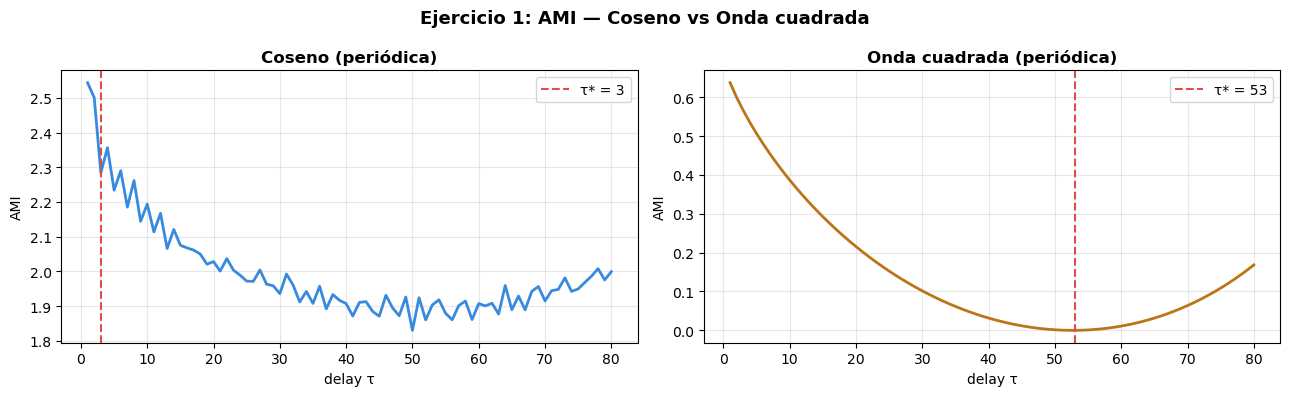

d* coseno:        2
d* onda cuadrada: 2


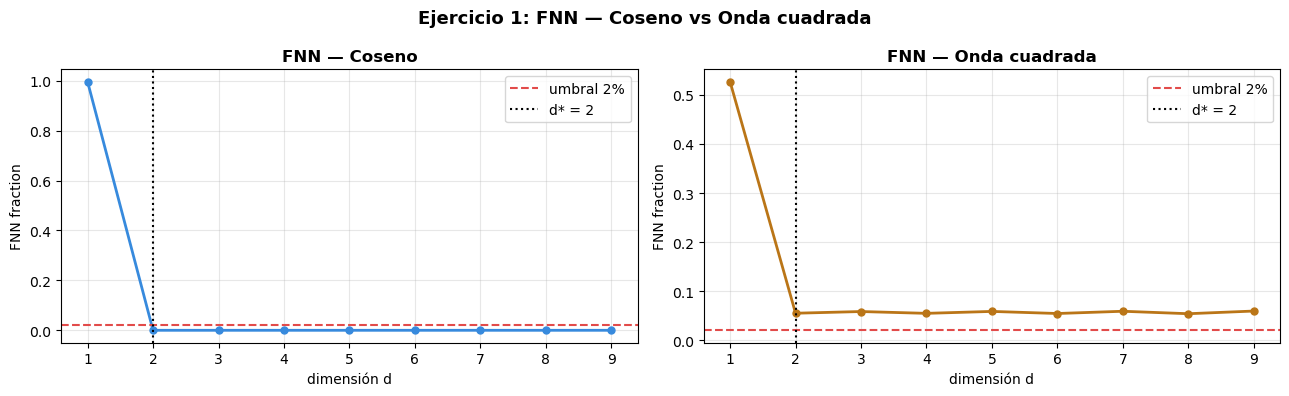

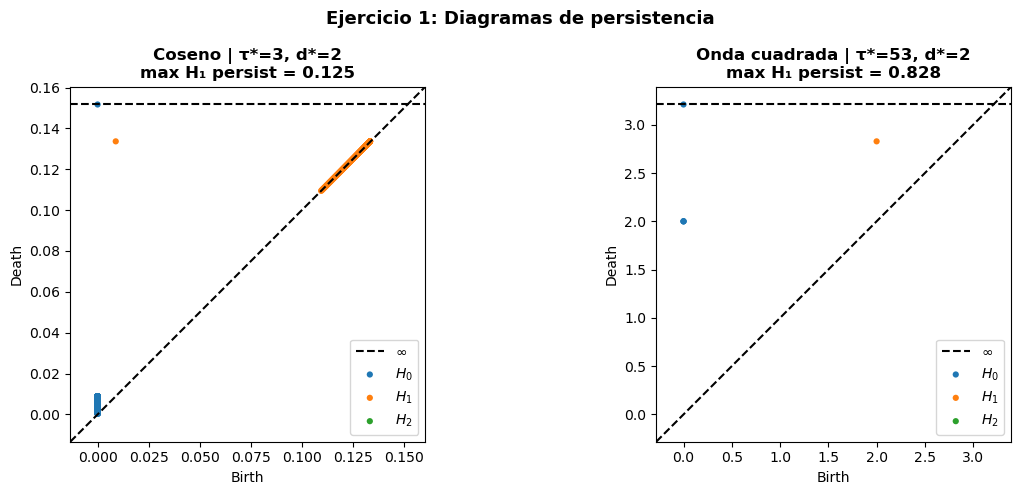

In [30]:
"""
═══════════════════════════════════════════════════════════════
EJERCICIO 1: Square wave vs señal periódica
═══════════════════════════════════════════════════════════════

ENUNCIADO:
  Replace the periodic signal by a square wave and compare
  AMI/FNN estimates.

OBJETIVO:
  Ver si una señal periódica NO sinusoidal (onda cuadrada)
  también forma una dona en el encaje y tiene β₁=1.

QUÉ SE ESPERA:
  - La onda cuadrada SÍ es periódica → debería formar un loop
  - Pero su forma es diferente al coseno → encaje diferente
  - AMI puede dar τ diferente (la onda cuadrada tiene
    discontinuidades que afectan la correlación)
  - FNN puede necesitar d más grande (geometría más compleja)
═══════════════════════════════════════════════════════════════
"""

# ── Generar la onda cuadrada ──────────────────────────────────
from scipy.signal import square

t = np.linspace(0, 10*np.pi, 1000)
# 1000 puntos entre 0 y 10π → misma longitud que el coseno

y_square = square(t)
# square(t) → onda cuadrada que alterna entre -1 y +1
# es periódica pero con saltos bruscos (no suave como coseno)

# ── Calcular AMI para ambas señales ──────────────────────────
ami_cos    = average_mutual_information(y_cos,    max_lag=80, bins=32)
ami_square = average_mutual_information(y_square, max_lag=80, bins=32)

# Encontrar τ* de cada una
tau_cos_ex1    = first_local_minimum(ami_cos)
tau_square_ex1 = first_local_minimum(ami_square)

print(f"τ* coseno:        {tau_cos_ex1}")
print(f"τ* onda cuadrada: {tau_square_ex1}")

# ── Graficar curvas AMI ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, ami, tau_opt, name, col in zip(
    axes,
    [ami_cos, ami_square],
    [tau_cos_ex1, tau_square_ex1],
    ['Coseno (periódica)', 'Onda cuadrada (periódica)'],
    ['#378ADD', '#BA7517']
):
    ax.plot(np.arange(1, 81), ami, color=col, lw=2)
    # Grafica la curva AMI vs τ
    
    ax.axvline(tau_opt, color='#E24B4A', ls='--', lw=1.5,
               label=f'τ* = {tau_opt}')
    # Marca el τ óptimo con línea punteada roja
    
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('delay τ')
    ax.set_ylabel('AMI')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Ejercicio 1: AMI — Coseno vs Onda cuadrada',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Calcular FNN para ambas señales ──────────────────────────
dims = np.arange(1, 10)  # probamos dimensiones del 1 al 9

fnn_cos    = [fnn_fraction(y_cos,    tau=tau_cos_ex1,    dim=d) for d in dims]
fnn_square = [fnn_fraction(y_square, tau=tau_square_ex1, dim=d) for d in dims]

# Encontrar d* de cada una (primer d donde FNN < 2%)
def find_d_star(vals, dims):
    candidate = np.where(np.array(vals) < 0.1)[0]
    return int(dims[candidate[0]]) if len(candidate) > 0 \
           else int(dims[np.argmin(vals)])

d_cos_ex1    = find_d_star(fnn_cos,    dims)
d_square_ex1 = find_d_star(fnn_square, dims)

print(f"d* coseno:        {d_cos_ex1}")
print(f"d* onda cuadrada: {d_square_ex1}")

# ── Graficar curvas FNN ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, fnn_vals, d_opt, name, col in zip(
    axes,
    [fnn_cos, fnn_square],
    [d_cos_ex1, d_square_ex1],
    ['Coseno', 'Onda cuadrada'],
    ['#378ADD', '#BA7517']
):
    ax.plot(dims, fnn_vals, '-o', color=col, ms=5, lw=2)
    # Grafica FNN vs dimensión
    
    ax.axhline(0.02, color='#E24B4A', ls='--', lw=1.5,
               label='umbral 2%')
    # Línea horizontal en el umbral de decisión
    
    ax.axvline(d_opt, color='k', ls=':', lw=1.5,
               label=f'd* = {d_opt}')
    # Línea vertical en d* óptimo
    
    ax.set_title(f'FNN — {name}', fontweight='bold')
    ax.set_xlabel('dimensión d')
    ax.set_ylabel('FNN fraction')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Ejercicio 1: FNN — Coseno vs Onda cuadrada',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Diagramas de persistencia de ambos encajes ───────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, signal, tau_opt, d_opt, name in zip(
    axes,
    [y_cos, y_square],
    [tau_cos_ex1, tau_square_ex1],
    [d_cos_ex1, d_square_ex1],
    ['Coseno', 'Onda cuadrada']
):
    # Construir el encaje con τ* y d* óptimos
    emb = delay_embedding(signal, tau=tau_opt, dim=d_opt)
    
    # Calcular diagrama de persistencia
    dgms = ripser(emb, maxdim=2)["dgms"]
    plot_diagrams(dgms, ax=ax, show=False)
    
    # Calcular persistencia máxima de H1
    h1 = dgms[1]
    h1_f = h1[np.isfinite(h1[:,1])]
    max_p = (h1_f[:,1] - h1_f[:,0]).max() if len(h1_f) else 0
    
    ax.set_title(f'{name} | τ*={tau_opt}, d*={d_opt}\n'
                 f'max H₁ persist = {max_p:.3f}',
                 fontweight='bold')

plt.suptitle('Ejercicio 1: Diagramas de persistencia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


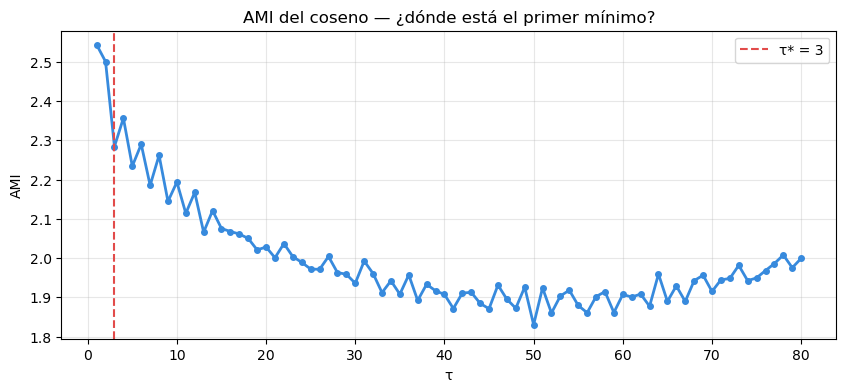

τ* encontrado: 3
Valores AMI primeros 10 τ:
  τ=1: 2.5435
  τ=2: 2.5006
  τ=3: 2.2842
  τ=4: 2.3564
  τ=5: 2.2341
  τ=6: 2.2899
  τ=7: 2.1852
  τ=8: 2.2618
  τ=9: 2.1443
  τ=10: 2.1937


In [34]:
# Corre esto para diagnosticar qué pasa con AMI del coseno
ami = average_mutual_information(y_cos, max_lag=80, bins=32)

plt.figure(figsize=(10,4))
plt.plot(np.arange(1, 81), ami, 'o-', color='#378ADD', lw=2, ms=4)
plt.axvline(first_local_minimum(ami), color='#E24B4A', ls='--',
            label=f'τ* = {first_local_minimum(ami)}')
plt.xlabel('τ')
plt.ylabel('AMI')
plt.title('AMI del coseno — ¿dónde está el primer mínimo?')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"τ* encontrado: {first_local_minimum(ami)}")
print(f"Valores AMI primeros 10 τ:")
for i, v in enumerate(ami[:10]):
    print(f"  τ={i+1}: {v:.4f}")

Usando τ fijo = 50
Usando τ fijo = 50


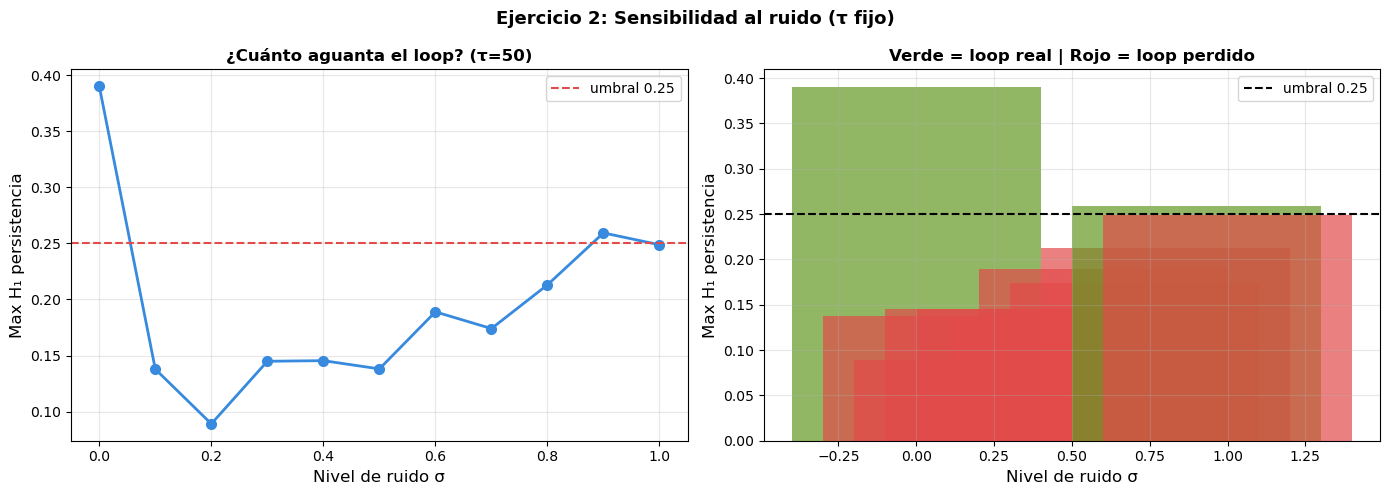

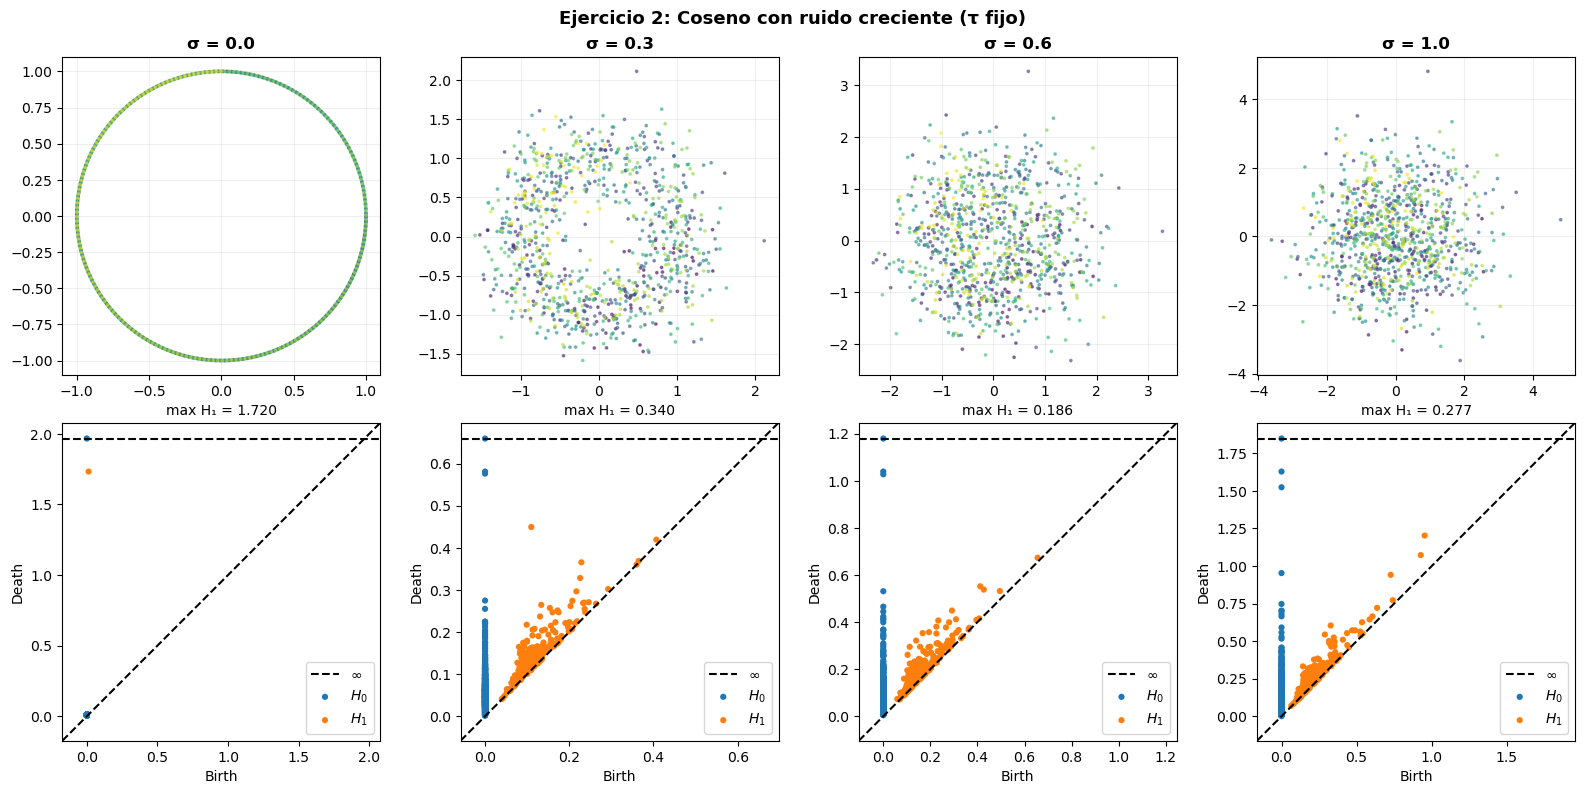


τ usado: 50

Persistencia por nivel de ruido:
  σ=0.0 → 0.3902  ✅ loop real
  σ=0.1 → 0.1379  ❌ loop perdido
  σ=0.2 → 0.0891  ❌ loop perdido
  σ=0.3 → 0.1449  ❌ loop perdido
  σ=0.4 → 0.1454  ❌ loop perdido
  σ=0.5 → 0.1381  ❌ loop perdido
  σ=0.6 → 0.1890  ❌ loop perdido
  σ=0.7 → 0.1741  ❌ loop perdido
  σ=0.8 → 0.2131  ❌ loop perdido
  σ=0.9 → 0.2594  ✅ loop real
  σ=1.0 → 0.2488  ❌ loop perdido


In [35]:
"""
═══════════════════════════════════════════════════════════════
EJERCICIO 2: Aumentar ruido y ver cómo cambia H1 (CORREGIDO)
═══════════════════════════════════════════════════════════════
CORRECCIÓN: τ fijo en lugar de recalcularlo para cada nivel
de ruido → así la única variable que cambia es el ruido,
no el τ también.
═══════════════════════════════════════════════════════════════
"""

np.random.seed(42)

# ── Niveles de ruido a probar ─────────────────────────────────
noise_levels = np.arange(0.0, 1.05, 0.1)
# [0.0, 0.1, 0.2, ..., 1.0] → 11 niveles

tau_fixed = 50
# τ=50 ≈ T/4 para el coseno con estos parámetros
# → dona bien formada desde σ=0
print(f"Usando τ fijo = {tau_fixed}")
# τ fijo del coseno → solo cambia el ruido, nada más
print(f"Usando τ fijo = {tau_fixed}")

max_h1_persist = []  # guardará la persistencia máxima de H1

# ── Calcular persistencia para cada nivel de ruido ────────────
# Usar bins más grandes en AMI para el ejercicio
for noise in noise_levels:
    y_noisy = np.cos(t) + np.random.normal(0, noise, len(t))
    
    ami = average_mutual_information(y_noisy, max_lag=80, bins=64)
    # ← bins=64 en lugar de 32
    tau = first_local_minimum(ami)
    
    emb = delay_embedding(y_noisy, tau=tau, dim=2)
    ...
    # encaje con τ FIJO → solo cambia el ruido

    dgms = ripser(emb, maxdim=1)["dgms"]
    # diagrama de persistencia

    h1 = dgms[1]
    h1_f = h1[np.isfinite(h1[:,1])]
    # filtra infinitos

    max_p = (h1_f[:,1] - h1_f[:,0]).max() if len(h1_f) else 0
    # máxima persistencia de H1

    max_h1_persist.append(max_p)

# ── Panel izquierdo: persistencia vs ruido ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(noise_levels, max_h1_persist,
             'o-', color='#378ADD', lw=2, ms=7)
# curva de persistencia vs nivel de ruido

axes[0].axhline(0.25, color='#E24B4A', ls='--', lw=1.5,
                label='umbral 0.25')
# línea horizontal en el umbral de "loop real"

axes[0].set_xlabel('Nivel de ruido σ', fontsize=12)
axes[0].set_ylabel('Max H₁ persistencia', fontsize=12)
axes[0].set_title(f'¿Cuánto aguanta el loop? (τ={tau_fixed})',
                  fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Panel derecho: punto de quiebre visual ────────────────────
# Encontrar el σ donde el loop cae debajo del umbral
quiebre = None
for noise, persist in zip(noise_levels, max_h1_persist):
    if persist < 0.25:
        quiebre = noise
        break

if quiebre:
    axes[1].bar(noise_levels, max_h1_persist,
                color=['#639922' if p >= 0.25 else '#E24B4A'
                       for p in max_h1_persist],
                alpha=0.7)
    # verde = loop real, rojo = loop perdido
    axes[1].axhline(0.25, color='k', ls='--', lw=1.5,
                    label='umbral 0.25')
    axes[1].set_xlabel('Nivel de ruido σ', fontsize=12)
    axes[1].set_ylabel('Max H₁ persistencia', fontsize=12)
    axes[1].set_title('Verde = loop real | Rojo = loop perdido',
                      fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

plt.suptitle('Ejercicio 2: Sensibilidad al ruido (τ fijo)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Visualización de 4 niveles de ruido ──────────────────────
fig2, axes2 = plt.subplots(2, 4, figsize=(16, 8))
sample_noises = [0.0, 0.3, 0.6, 1.0]

for i, noise in enumerate(sample_noises):
    np.random.seed(42)  # misma semilla para comparar
    y_noisy = np.cos(t) + np.random.normal(0, noise, len(t))
    emb = delay_embedding(y_noisy, tau=tau_fixed, dim=2)
    dgms = ripser(emb, maxdim=1)["dgms"]

    # Fila 1: encaje 2D
    axes2[0,i].scatter(emb[:,0], emb[:,1],
                       s=3,
                       c=np.arange(len(emb)),
                       cmap='viridis',
                       alpha=0.5)
    # colorea por tiempo: azul=inicio, amarillo=final
    axes2[0,i].set_title(f'σ = {noise}', fontweight='bold')
    axes2[0,i].set_aspect('equal')
    axes2[0,i].grid(alpha=0.2)

    # Fila 2: diagrama de persistencia
    plot_diagrams(dgms, ax=axes2[1,i], show=False)
    h1 = dgms[1]
    h1_f = h1[np.isfinite(h1[:,1])]
    max_p = (h1_f[:,1]-h1_f[:,0]).max() if len(h1_f) else 0
    axes2[1,i].set_title(f'max H₁ = {max_p:.3f}', fontsize=10)

fig2.suptitle('Ejercicio 2: Coseno con ruido creciente (τ fijo)',
              fontsize=13, fontweight='bold')
fig2.tight_layout()
plt.show()

# ── Veredicto ─────────────────────────────────────────────────
print(f"\nτ usado: {tau_fixed}")
print(f"\nPersistencia por nivel de ruido:")
for noise, persist in zip(noise_levels, max_h1_persist):
    estado = "✅ loop real" if persist >= 0.25 else "❌ loop perdido"
    print(f"  σ={noise:.1f} → {persist:.4f}  {estado}")

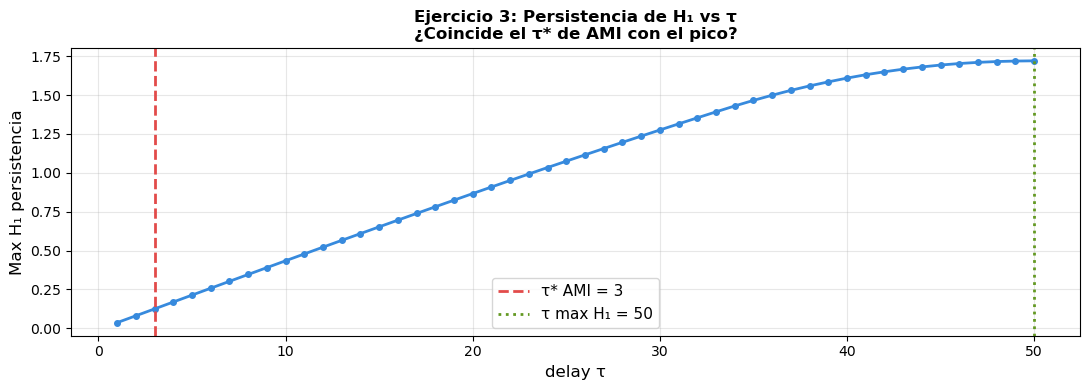

τ* elegido por AMI:          3
τ que maximiza H₁ persist:   50
Diferencia:                  47
→ AMI no coincide exactamente pero es una heurística ⚠️


In [36]:
"""
═══════════════════════════════════════════════════════════════
EJERCICIO 3: Barrer τ sistemáticamente
═══════════════════════════════════════════════════════════════

ENUNCIADO:
  Fix a signal and sweep τ systematically; plot max H1
  persistence vs τ.

OBJETIVO:
  Confirmar VISUALMENTE que el τ elegido por AMI (primer
  mínimo) es realmente el que maximiza la persistencia de H1.

QUÉ SE ESPERA:
  - La curva tiene un PICO en el τ óptimo elegido por AMI
  - Con τ muy chico → persistencia baja (dona aplastada)
  - Con τ muy grande → persistencia baja (dona destruida)
  - El pico coincide (o está cerca) del τ* de AMI
═══════════════════════════════════════════════════════════════
"""

# ── Barrer τ de 1 a 50 con la señal periódica ────────────────
tau_values = np.arange(1, 51)
# [1, 2, 3, ..., 50] → todos los τ a probar

max_h1_per_tau = []  # persistencia máxima para cada τ

for tau in tau_values:
    # Construir encaje con d=2 fijo, τ variable
    emb = delay_embedding(y_cos, tau=tau, dim=2)
    
    # Calcular diagrama de persistencia
    dgms = ripser(emb, maxdim=1)["dgms"]
    h1 = dgms[1]
    h1_f = h1[np.isfinite(h1[:,1])]
    
    max_p = (h1_f[:,1] - h1_f[:,0]).max() if len(h1_f) else 0
    max_h1_per_tau.append(max_p)

# ── Graficar max H1 vs τ ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))

ax.plot(tau_values, max_h1_per_tau,
        'o-', color='#378ADD', lw=2, ms=4)
# Curva de persistencia vs τ

ax.axvline(tau_cos_ex1, color='#E24B4A', ls='--', lw=2,
           label=f'τ* AMI = {tau_cos_ex1}')
# Marca el τ elegido por AMI con línea roja

# Marca el τ con máxima persistencia
tau_best = tau_values[np.argmax(max_h1_per_tau)]
ax.axvline(tau_best, color='#639922', ls=':', lw=2,
           label=f'τ max H₁ = {tau_best}')
# Línea verde en el τ que maximiza la persistencia

ax.set_xlabel('delay τ', fontsize=12)
ax.set_ylabel('Max H₁ persistencia', fontsize=12)
ax.set_title('Ejercicio 3: Persistencia de H₁ vs τ\n'
             '¿Coincide el τ* de AMI con el pico?',
             fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"τ* elegido por AMI:          {tau_cos_ex1}")
print(f"τ que maximiza H₁ persist:   {tau_best}")
diff = abs(tau_cos_ex1 - tau_best)
print(f"Diferencia:                  {diff}")
if diff <= 5:
    print("→ AMI es una buena guía para elegir τ ")
else:
    print("→ AMI no coincide exactamente pero es una heurística ⚠️")

Señales generadas:
  Periódica:     cos(t)
  Quasi-periód.: cos(t) + 0.5·cos(1.618·t)
  Frecuencia dominante: igual en ambas (f=1)


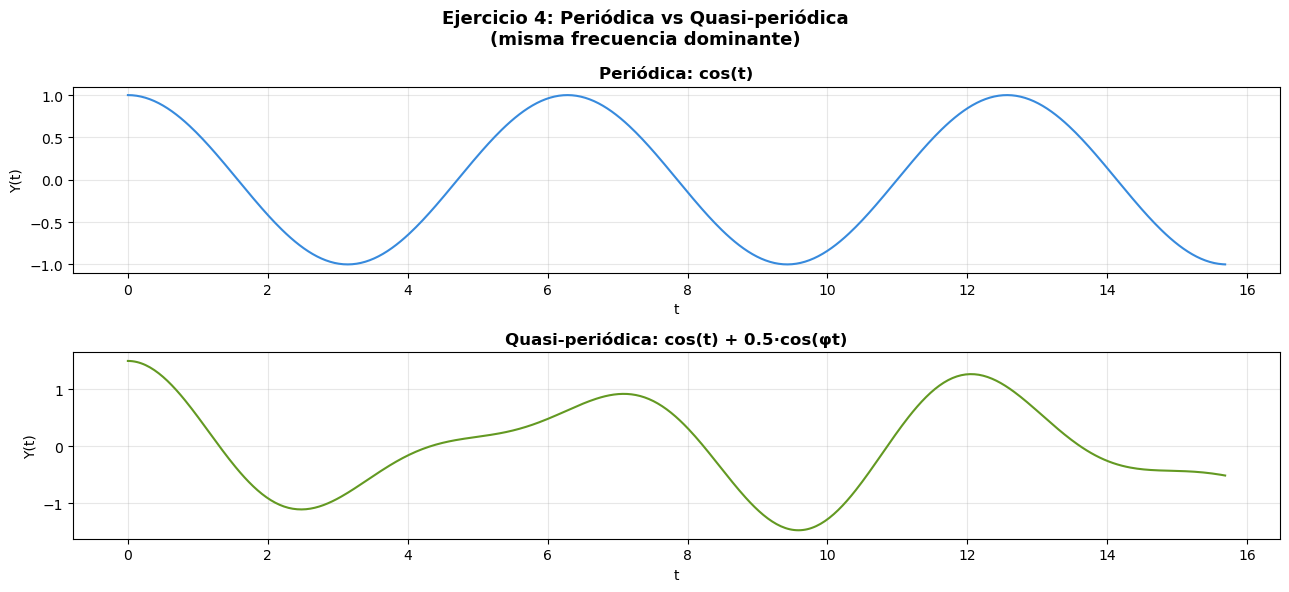


τ* periódica:       3
τ* quasi-periódica: 30


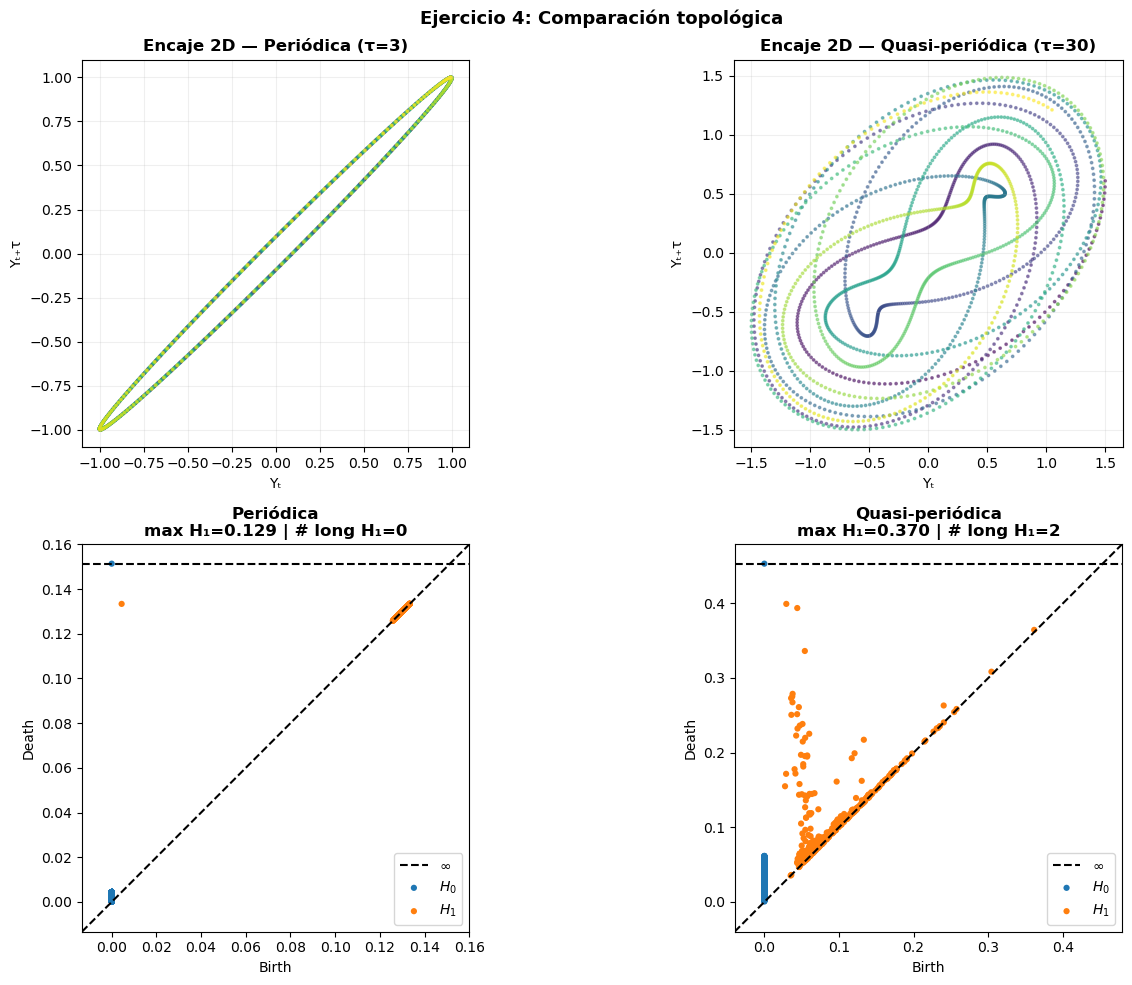


=== VEREDICTO EJERCICIO 4 ===
Periódica         : max H₁=0.129 | # long=0 | NO PERIÓDICA 
Quasi-periódica   : max H₁=0.370 | # long=2 | QUASI-PERIÓDICA ⚠️ — varios loops

DIFERENCIA TOPOLÓGICA CLAVE:
  Periódica:       encaje → ELIPSE → β₁=1 (un loop)
                   trayectoria cierra sobre sí misma exactamente

  Quasi-periódica: encaje → ESPIRAL sobre TORO → β₁=2
                   trayectoria NUNCA cierra exactamente
                   → rellena una superficie (el toro)
                   → dos loops independientes



In [37]:
"""
═══════════════════════════════════════════════════════════════
EJERCICIO 4: Periódica vs Quasi-periódica
═══════════════════════════════════════════════════════════════

ENUNCIADO:
  Compare periodic vs quasi-periodic signals with the same
  dominant frequency and discuss topological differences.

OBJETIVO:
  Mostrar que dos señales con la MISMA frecuencia dominante
  pueden tener topología MUY diferente:
  - Periódica: β₁ = 1 (una elipse / dona)
  - Quasi-periódica: β₁ = 2 (toro)

QUÉ SE ESPERA:
  - Diagramas de persistencia diferentes
  - Quasi-periódica tiene MÁS features H₁ persistentes
  - El encaje 3D es diferente: elipse vs espiral sobre toro
═══════════════════════════════════════════════════════════════
"""

# ── Generar ambas señales con la MISMA frecuencia dominante ──
t = np.linspace(0, 20*np.pi, 2000)
# Señal más larga para ver mejor la quasi-periodicidad

# Periódica: coseno simple
y_periodic = np.cos(t)
# Una sola frecuencia: f=1

# Quasi-periódica: suma de dos cosenos con frecuencias
# en ratio irracional → NUNCA se repite exactamente
ratio = (1 + np.sqrt(5)) / 2  # número áureo ≈ 1.618
y_quasi = np.cos(t) + 0.5 * np.cos(ratio * t)
# Misma frecuencia dominante (cos(t)) pero con una segunda
# frecuencia (cos(1.618t)) que hace que nunca repita

print("Señales generadas:")
print(f"  Periódica:     cos(t)")
print(f"  Quasi-periód.: cos(t) + 0.5·cos({ratio:.3f}·t)")
print(f"  Frecuencia dominante: igual en ambas (f=1)")

# ── Visualizar las señales ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 6))

for ax, signal, name, col in zip(
    axes,
    [y_periodic, y_quasi],
    ['Periódica: cos(t)', 'Quasi-periódica: cos(t) + 0.5·cos(φt)'],
    ['#378ADD', '#639922']
):
    ax.plot(t[:500], signal[:500], color=col, lw=1.5)
    # Muestra los primeros 500 puntos para ver el patrón
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('t')
    ax.set_ylabel('Y(t)')
    ax.grid(alpha=0.3)

plt.suptitle('Ejercicio 4: Periódica vs Quasi-periódica\n'
             '(misma frecuencia dominante)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Calcular τ* con AMI para cada señal ──────────────────────
ami_p = average_mutual_information(y_periodic, max_lag=80, bins=32)
ami_q = average_mutual_information(y_quasi,    max_lag=80, bins=32)

tau_p = first_local_minimum(ami_p)
tau_q = first_local_minimum(ami_q)

print(f"\nτ* periódica:       {tau_p}")
print(f"τ* quasi-periódica: {tau_q}")

# ── Construir encajes y calcular diagramas ────────────────────
emb_p = delay_embedding(y_periodic, tau=tau_p, dim=2)
emb_q = delay_embedding(y_quasi,    tau=tau_q, dim=2)

dgms_p = ripser(emb_p, maxdim=1)["dgms"]
dgms_q = ripser(emb_q, maxdim=1)["dgms"]

# ── Visualización completa: encaje + diagrama ─────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Fila 1: encajes 2D
for ax, emb, name, col in zip(
    axes[0],
    [emb_p, emb_q],
    [f'Periódica (τ={tau_p})', f'Quasi-periódica (τ={tau_q})'],
    ['#378ADD', '#639922']
):
    ax.scatter(emb[:,0], emb[:,1],
               s=3, c=np.arange(len(emb)),
               cmap='viridis', alpha=0.5)
    # Colorea por tiempo: azul=inicio, amarillo=final
    ax.set_title(f'Encaje 2D — {name}', fontweight='bold')
    ax.set_xlabel('Yₜ')
    ax.set_ylabel('Yₜ₊τ')
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)

# Fila 2: diagramas de persistencia
for ax, dgms, name in zip(
    axes[1],
    [dgms_p, dgms_q],
    ['Periódica', 'Quasi-periódica']
):
    plot_diagrams(dgms, ax=ax, show=False)
    
    # Calcular estadísticas de H1
    h1 = dgms[1]
    h1_f = h1[np.isfinite(h1[:,1])]
    persist = h1_f[:,1] - h1_f[:,0] if len(h1_f) else np.array([])
    n_long = (persist > 0.3).sum() if len(persist) else 0
    max_p  = persist.max() if len(persist) else 0
    
    ax.set_title(f'{name}\nmax H₁={max_p:.3f} | # long H₁={n_long}',
                 fontweight='bold')

plt.suptitle('Ejercicio 4: Comparación topológica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Veredicto comparativo ─────────────────────────────────────
print("\n=== VEREDICTO EJERCICIO 4 ===")
for dgms, name in zip([dgms_p, dgms_q],
                       ['Periódica', 'Quasi-periódica']):
    h1 = dgms[1]
    h1_f = h1[np.isfinite(h1[:,1])]
    persist = h1_f[:,1] - h1_f[:,0] if len(h1_f) else np.array([])
    n_long = (persist > 0.3).sum() if len(persist) else 0
    max_p  = persist.max() if len(persist) else 0
    
    if n_long == 1:
        tipo = "PERIÓDICA — 1 loop dominante"
    elif n_long >= 2:
        tipo = "QUASI-PERIÓDICA ⚠️ — varios loops"
    else:
        tipo = "NO PERIÓDICA "
    
    print(f"{name:<18}: max H₁={max_p:.3f} | "
          f"# long={n_long} | {tipo}")

print("""
DIFERENCIA TOPOLÓGICA CLAVE:
  Periódica:       encaje → ELIPSE → β₁=1 (un loop)
                   trayectoria cierra sobre sí misma exactamente
  
  Quasi-periódica: encaje → ESPIRAL sobre TORO → β₁=2
                   trayectoria NUNCA cierra exactamente
                   → rellena una superficie (el toro)
                   → dos loops independientes
""")